In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
X, y = load_diabetes(return_X_y=True)
X=X[:,[2]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)


LInear Regression Model

In [8]:
from sklearn.linear_model import LinearRegression
regressor =LinearRegression().fit(X_train,y_train)


Model Evaluation

In [9]:
from sklearn.metrics import mean_squared_error ,r2_score
y_pred=regressor.predict(X_test)
print(f"Mean squared error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"Coefficient of determination:{r2_score(y_test,y_pred):.2f}")

Mean squared error:2548.07
Coefficient of determination:0.47


PLOTTING THE RESULTS

In [10]:
import matplotlib.pyplot as plt

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    if tight_layout:
        plt.tight_layout()
    plt.savefig(f"{fig_id}.{fig_extension}", format=fig_extension, dpi=resolution)

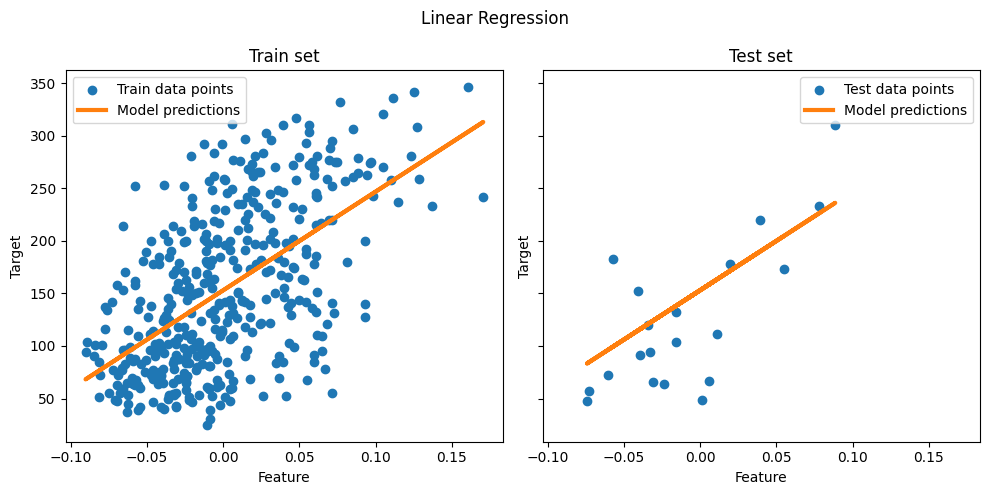

In [11]:


fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train[:, 0], y_train, label="Train data points")
ax[0].plot(
    X_train[:, 0],
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test[:, 0], y_test, label="Test data points")
ax[1].plot(X_test[:, 0], y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")
save_fig("linear regression_plot")

plt.show()

OLS on this single-feature subset learns a linear function that minimizes the mean squared error on the training data. We can see how well (or poorly) it generalizes by looking at the R^2 score and mean squared error on the test set. In higher dimensions, pure OLS often overfits, especially if the data is noisy. Regularization techniques (like Ridge or Lasso) can help reduce that.

<h1>Ordinary Least Squares and Ridge Regression Variance</h1>


Next, we illustrate the problem of high variance more clearly by using a tiny synthetic dataset. We sample only two data points, then repeatedly add small Gaussian noise to them and refit both OLS and Ridge. We plot each new line to see how much OLS can jump around, whereas Ridge remains more stable thanks to its penalty term.

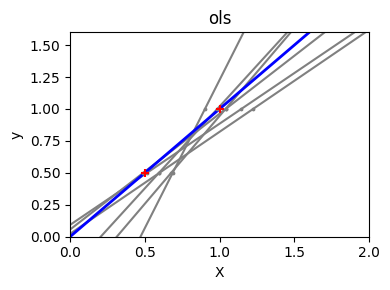

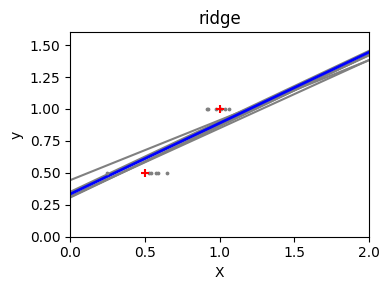

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(this_X, y_train, s=3, c="gray", marker="o", zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel("X")
    ax.set_ylabel("y")

    fig.tight_layout()
    save_fig(f"{name}_regression_variance_plot")

plt.show()

Conclusion

In the first example, we applied OLS to a real dataset, showing how a plain linear model can fit the data by minimizing the squared error on the training set.

In the second example, OLS lines varied drastically each time noise was added, reflecting its high variance when data is sparse or noisy. By contrast, Ridge regression introduces a regularization term that shrinks the coefficients, stabilizing predictions.

Techniques like Ridge or Lasso (which applies an L1 penalty) are both common ways to improve generalization and reduce overfitting. A well-tuned Ridge or Lasso often outperforms pure OLS when features are correlated, data is noisy, or sample size is small.